In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

In [3]:
# === Load the Drug–ADR matrix ===
matrix = np.loadtxt("drug_se_mat.txt")
matrix

array([[1., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [4]:
# Each row = drug, each column = ADR
n_drugs, n_adrs = matrix.shape
print(f"Matrix shape: {n_drugs} drugs × {n_adrs} ADRs")

Matrix shape: 1177 drugs × 4247 ADRs


In [5]:
# === Compute ADR counts per drug ===
adr_counts = matrix.sum(axis=1)  # number of 1's per drug
adr_counts

array([ 98., 110., 365., ...,  60.,  19.,  18.])

In [6]:
# === Load mapping for labels (optional, for debugging or tooltips) ===
with open("drug2id.json") as f:
    drug2id = json.load(f)
id2drug = {v: k for k, v in drug2id.items()}

In [7]:
# === Sort to show head–tail behavior ===
adr_counts_sorted = np.sort(adr_counts)[::-1]

In [8]:
adr_counts_sorted

array([742., 742., 720., ...,   1.,   1.,   1.])

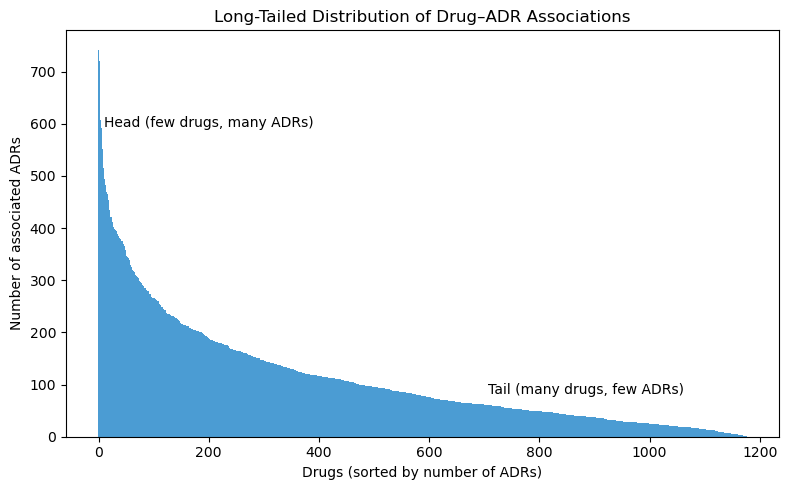

In [9]:
# === Plot ===
plt.figure(figsize=(8, 5))
plt.bar(range(len(adr_counts_sorted)), adr_counts_sorted, color="#4B9CD3", width=1.0)
#plt.yscale("log")  # log-scale optional; comment out if you prefer linear
plt.xlabel("Drugs (sorted by number of ADRs)")
plt.ylabel("Number of associated ADRs")
plt.title("Long-Tailed Distribution of Drug–ADR Associations")

# Optional annotation for visual clarity
plt.text(10, adr_counts_sorted[0] * 0.8, "Head (few drugs, many ADRs)", fontsize=10, color='black')
plt.text(len(adr_counts_sorted) * 0.6, adr_counts_sorted[-1] + 80, "Tail (many drugs, few ADRs)", fontsize=10, color='black')

plt.tight_layout()
plt.savefig("adr_longtail_distribution.png", dpi=300)
plt.show()

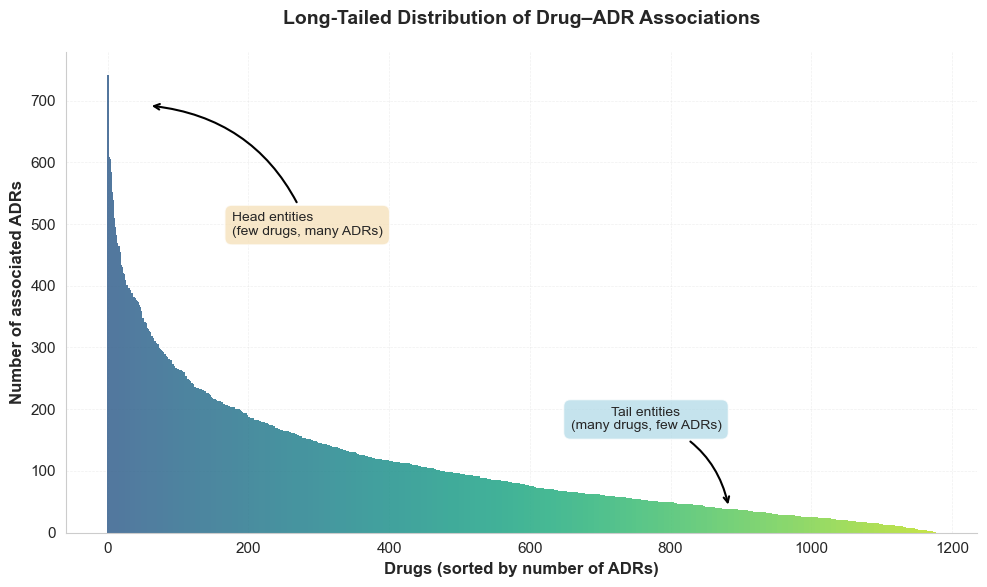

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 11

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

# Create gradient color effect
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(adr_counts_sorted)))

# Plot with gradient
bars = ax.bar(range(len(adr_counts_sorted)), adr_counts_sorted, 
              color=colors, width=1.0, edgecolor='none', alpha=0.85)

# Styling
ax.set_xlabel("Drugs (sorted by number of ADRs)", fontsize=12, fontweight='bold')
ax.set_ylabel("Number of associated ADRs", fontsize=12, fontweight='bold')
ax.set_title("Long-Tailed Distribution of Drug–ADR Associations", 
             fontsize=14, fontweight='bold', pad=20)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotations with better positioning and styling
head_y = adr_counts_sorted[0] * 0.65
tail_y = max(adr_counts_sorted[-1] + 55, adr_counts_sorted.max() * 0.05)

# Head annotation with arrow
ax.annotate('Head entities\n(few drugs, many ADRs)', 
            xy=(len(adr_counts_sorted) * 0.05, adr_counts_sorted[0] - 50), 
            xytext=(len(adr_counts_sorted) * 0.15, head_y),
            fontsize=10, ha='left',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                          color='black', lw=1.5))

# Tail annotation with arrow
ax.annotate('Tail entities\n(many drugs, few ADRs)', 
            xy=(len(adr_counts_sorted) * 0.75, adr_counts_sorted[-1] + 40), 
            xytext=(len(adr_counts_sorted) * 0.65, tail_y + adr_counts_sorted.max() * 0.15),
            fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', 
                          color='black', lw=1.5))

plt.tight_layout()
plt.savefig("adr_longtail_distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# === Summary statistics ===
print(f"Mean ADRs per drug: {adr_counts.mean():.2f}")
print(f"Median ADRs per drug: {np.median(adr_counts):.2f}")
print(f"Max ADRs per drug: {adr_counts.max()}")
print(f"Drugs with zero ADRs: {(adr_counts == 0).sum()}")

Mean ADRs per drug: 111.48
Median ADRs per drug: 79.00
Max ADRs per drug: 742.0
Drugs with zero ADRs: 0
